In [1]:
# %%
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("🚀 Step 1: Loading Processed Data...")

DATA_PROCESSED = os.path.join("..", "data", "processed")
file_path = os.path.join(DATA_PROCESSED, "processed_all_households_blind.csv")

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Missing {file_path}. Please run the 02_data_processing notebook first.")

df = pd.read_csv(file_path)
print(f"✅ Loaded dataset: {df.shape[0]} households.")
print(f"✅ Class Distribution:\n{df['TARGET_GAP'].value_counts(normalize=True)*100}")

/Users/zhenyuyue/miniforge3/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


🚀 Step 1: Loading Processed Data...
✅ Loaded dataset: 61071 households.
✅ Class Distribution:
TARGET_GAP
0    91.929066
1     8.070934
Name: proportion, dtype: float64


In [2]:
# %%
print("✂️ Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...")

# Define features (X) and target (y)
# We drop SERIALNO (ID) and PUMA (Geography) as they are not standard numerical proxies
X = df.drop(columns=['SERIALNO', 'PUMA', 'TARGET_GAP'])
y = df['TARGET_GAP']

# 1st Split: 70% Train, 30% Temporary Holdout (Val + Test)
# stratify=y ensures the small "Gap" class is distributed evenly across the splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2nd Split: Split the 30% holdout exactly in half (15% Validate, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"✅ Training set:   {X_train.shape[0]} rows")
print(f"✅ Validation set: {X_val.shape[0]} rows")
print(f"✅ Test set:       {X_test.shape[0]} rows")

✂️ Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...
✅ Training set:   42749 rows
✅ Validation set: 9161 rows
✅ Test set:       9161 rows


In [3]:
# %%
print("⚙️ Step 3: Scaling Features and Training Baseline Model...")

# Features like NUM_CHILDREN (0-5) and GRPIP (Rent % 0-100) are on different scales.
# Logistic Regression requires them to be standardized.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage from the validation/test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize the model
# class_weight='balanced' is critical here. Since the Gap is a minority class in the general population,
# this forces the model to heavily penalize missing a Gap household.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression Model trained successfully!")

⚙️ Step 3: Scaling Features and Training Baseline Model...
✅ Logistic Regression Model trained successfully!


📊 Step 4: Evaluating on Validation Set...

--- Classification Report ---
                precision    recall  f1-score   support

Not in Gap (0)       0.97      0.74      0.84      8421
   The Gap (1)       0.20      0.74      0.31       740

      accuracy                           0.74      9161
     macro avg       0.58      0.74      0.58      9161
  weighted avg       0.91      0.74      0.80      9161



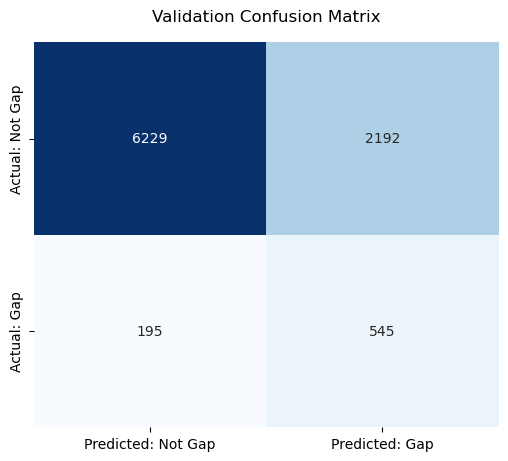

In [4]:
# %%
print("📊 Step 4: Evaluating on Validation Set...")

# Predict on validation data
y_val_pred = model.predict(X_val_scaled)

print("\n--- Classification Report ---")
# 0 = Not in Gap, 1 = The Gap
print(classification_report(y_val, y_val_pred, target_names=["Not in Gap (0)", "The Gap (1)"]))

# Plotting the Confusion Matrix for better visual interpretation
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted: Not Gap", "Predicted: Gap"],
            yticklabels=["Actual: Not Gap", "Actual: Gap"])
plt.title('Validation Confusion Matrix', pad=15)
plt.show()

🔍 Step 5: Analyzing the Proxies (What predicts the Gap?)

📈 POSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.
📉 NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.



,Feature,Coefficient
9,GRPIP,0.456862
12,NP,0.331086
7,ACCESSINET,0.145128
5,IS_MINORITY_HH,0.084584
8,LNGI,0.064788
1,HAS_DISABLED,0.021554
6,VEH,-0.029187
11,TEN,-0.039844
10,RMSP,-0.052338
2,NUM_CHILDREN,-0.132597


/var/folders/0s/d2ycgfq576zdm73qwlf4r6gc0000gn/T/ipykernel_74525/3739815230.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=df_coef, palette='coolwarm')


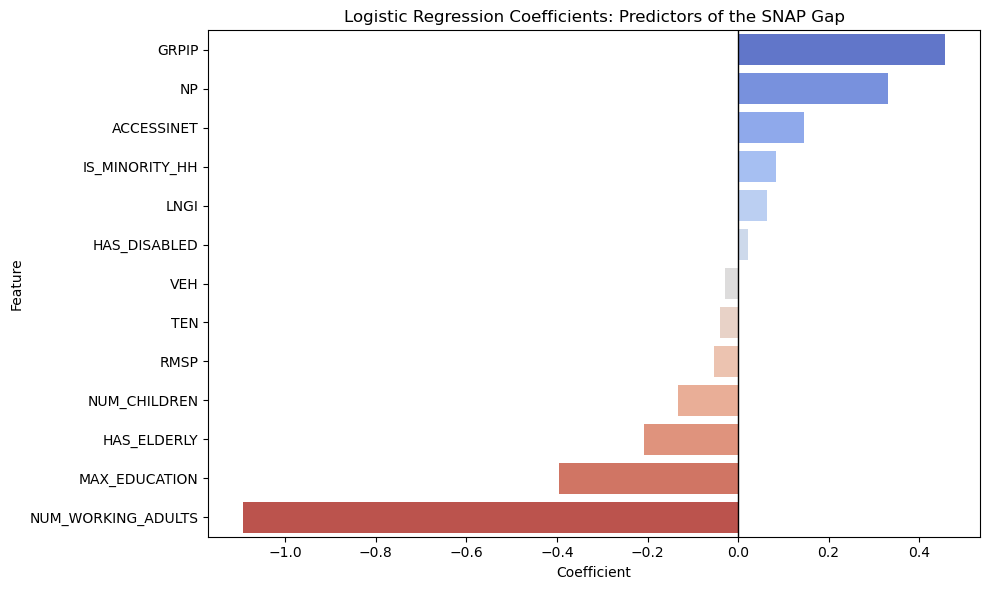

In [6]:
# %%
print("🔍 Step 5: Analyzing the Proxies (What predicts the Gap?)")

# Extract coefficients and map them back to the original feature names
coefficients = model.coef_[0]
feature_names = X.columns

# Create a clean DataFrame
df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by impact
df_coef = df_coef.sort_values(by='Coefficient', ascending=False)

print("\n📈 POSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.")
print("📉 NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.\n")

display(df_coef)

# Optional Visual Plot of the Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=df_coef, palette='coolwarm')
plt.title('Logistic Regression Coefficients: Predictors of the SNAP Gap')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()